<a href="https://colab.research.google.com/github/Paras1719/NNDL-practicals/blob/main/NNDL_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import datasets, layers, models
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from google.colab import files
from PIL import Image

In [ ]:
(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()


# Class names
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

In [ ]:

# Display Dataset Information

print("Dataset Information")
print("-------------------")

print("Training images :", x_train.shape)
print("Training labels :", y_train.shape)

print("Testing images  :", x_test.shape)
print("Testing labels  :", y_test.shape)

print("Number of classes:", len(class_names))

Dataset Information
-------------------
Training images : (60000, 28, 28)
Training labels : (60000,)
Testing images  : (10000, 28, 28)
Testing labels  : (10000,)
Number of classes: 10


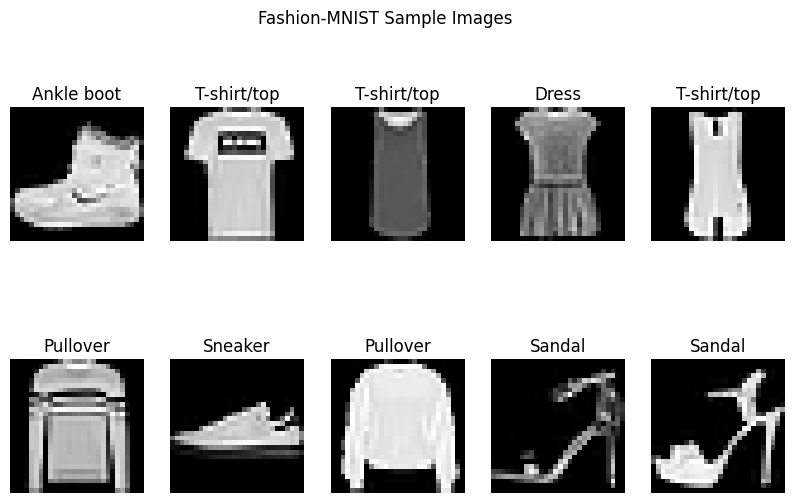

In [ ]:
# 4. Display Sample Images

plt.figure(figsize=(10, 6))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(x_train[i], cmap='gray')

    plt.title(class_names[y_train[i]])

    plt.axis('off')

plt.suptitle("Fashion-MNIST Sample Images")

plt.show()

In [ ]:
# 5. Normalize Image Data

x_train = x_train / 255.0
x_test = x_test / 255.0


print("\nImage Information")
print("-----------------")

print("Image size :", x_train.shape[1:])

print("Pixel value : 0 to 1 after normalization")


Image Information
-----------------
Image size : (28, 28)
Pixel value : 0 to 1 after normalization


In [ ]:
# 6. Reshape Images for CNN
x_train = x_train.reshape(-1, 28, 28, 1)

x_test = x_test.reshape(-1, 28, 28, 1)


print("\nAfter Reshaping")
print("----------------")

print("Training images :", x_train.shape)
print("Testing images  :", x_test.shape)


After Reshaping
----------------
Training images : (60000, 28, 28, 1)
Testing images  : (10000, 28, 28, 1)


In [ ]:
# 7. Build CNN Model
model = models.Sequential([
    # First Convolution Layer
    layers.Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    # Pooling
    layers.MaxPooling2D((2, 2)),

    # Second Convolution Layer
    layers.Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),

    # Pooling
    layers.MaxPooling2D((2, 2)),
    # Convert feature maps to 1D
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(
        64,
        activation='relu'
    ),

    # Output Layer
    # 10 neurons = 10 classes
    layers.Dense(
        10,
        activation='softmax'
    )

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 8. Display CNN Model Information

print("\nCNN Model Information")
print("---------------------")

model.summary()


CNN Model Information
---------------------


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 9. Compile Model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


print("\nModel compiled successfully.")


Model compiled successfully.


In [ ]:
# 10. Train CNN Model

print("\nTraining CNN Model")
print("------------------")

history = model.fit(

    x_train,
    y_train,
    epochs=5,
    batch_size=64,

    validation_split=0.1
)


Training CNN Model
------------------
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 64s 72ms/step - accuracy: 0.8070 - loss: 0.5354 - val_accuracy: 0.8637 - val_loss: 0.3850
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 117s 115ms/step - accuracy: 0.8725 - loss: 0.3524 - val_accuracy: 0.8767 - val_loss: 0.3335
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 97s 61ms/step - accuracy: 0.8886 - loss: 0.3041 - val_accuracy: 0.8907 - val_loss: 0.3023
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 78s 56ms/step - accuracy: 0.9009 - loss: 0.2726 - val_accuracy: 0.8990 - val_loss: 0.2773
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 86s 62ms/step - accuracy: 0.9086 - loss: 0.2486 - val_accuracy: 0.9008 - val_loss: 0.2718


In [ ]:
# 11. Training Information
print("\nTraining Information")
print("--------------------")

print(
    "Final Training Accuracy :",
    history.history['accuracy'][-1]
)

print(
    "Final Validation Accuracy :",
    history.history['val_accuracy'][-1]
)

print(
    "Final Training Loss :",
    history.history['loss'][-1]
)

print(
    "Final Validation Loss :",
    history.history['val_loss'][-1]
)


Training Information
--------------------
Final Training Accuracy : 0.9085555672645569
Final Validation Accuracy : 0.9008333086967468
Final Training Loss : 0.24859710037708282
Final Validation Loss : 0.27181902527809143


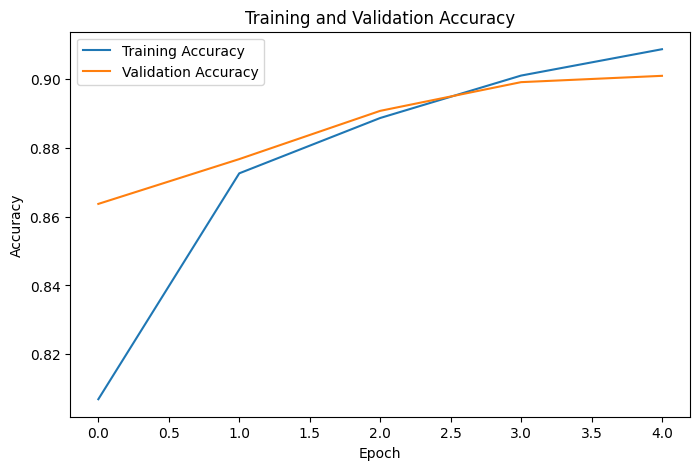

In [ ]:
# 12. Plot Training and Validation Accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training and Validation Accuracy")

plt.legend()

plt.show()

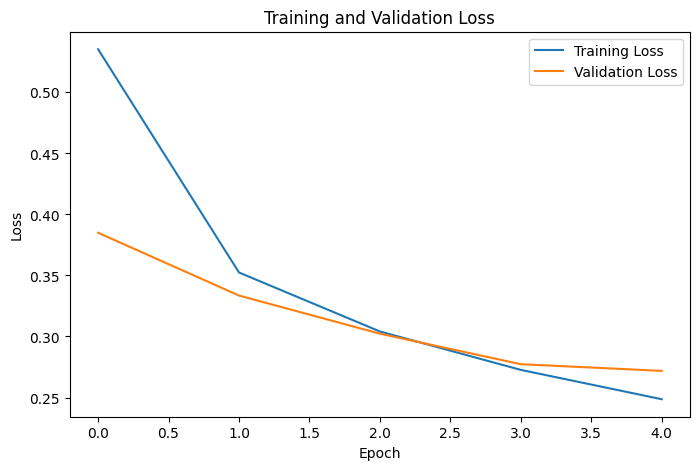

In [ ]:
# 13. Plot Training and Validation Loss

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training and Validation Loss")

plt.legend()

plt.show()

In [ ]:
# 14. Evaluate Model on Test Dataset

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)


print("\nTest Information")
print("----------------")

print("Test Loss     :", test_loss)

print("Test Accuracy :", test_accuracy)

print(
    "Test Accuracy (%):",
    round(test_accuracy * 100, 2),
    "%"
)


Test Information
----------------
Test Loss     : 0.2872105836868286
Test Accuracy : 0.897599995136261
Test Accuracy (%): 89.76 %


In [ ]:
# 15. Make Predictions

y_prediction = model.predict(x_test)

# Get class with highest probability
y_pred = np.argmax(
    y_prediction,
    axis=1
)


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


In [ ]:
# 16. Classification Report

print("\nClassification Report")
print("---------------------")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names
    )
)


Classification Report
---------------------
              precision    recall  f1-score   support

 T-shirt/top       0.85      0.86      0.86      1000
     Trouser       1.00      0.97      0.98      1000
    Pullover       0.89      0.77      0.82      1000
       Dress       0.91      0.91      0.91      1000
        Coat       0.77      0.91      0.83      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.72      0.68      0.70      1000
     Sneaker       0.93      0.98      0.95      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.98      0.96      0.97      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



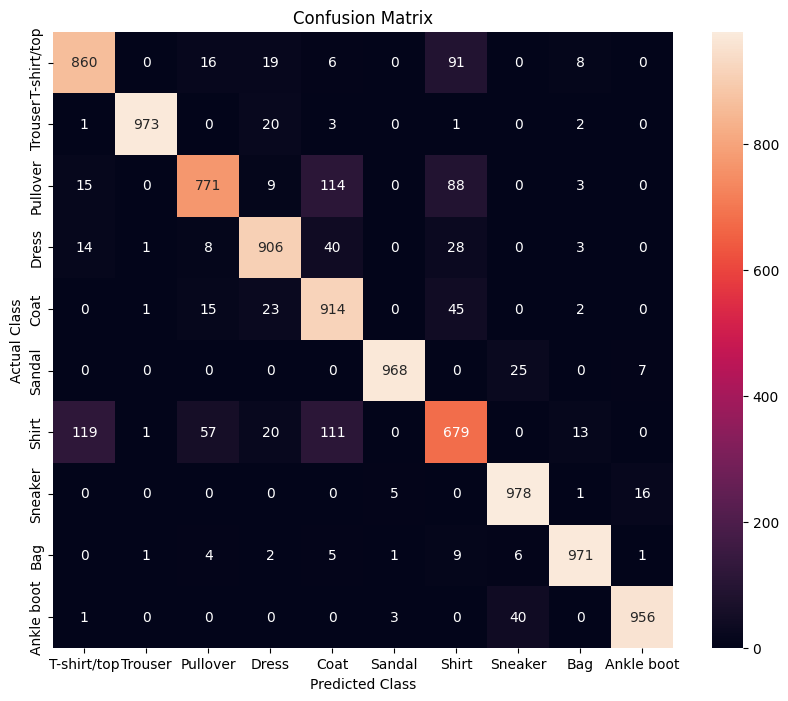

In [ ]:
# 17. Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred
)
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")

plt.ylabel("Actual Class")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
# 18. Image Identification

index = 100


# Select image
image = x_test[index]


# Predict image
prediction = model.predict(
    image.reshape(1, 28, 28, 1),
    verbose=0
)


# Get predicted class
predicted_class = np.argmax(
    prediction
)


# Get confidence
confidence = prediction[0][predicted_class] * 100


print("\nImage Identification")
print("--------------------")

print(
    "Actual Class    :",
    class_names[y_test[index]]
)

print(
    "Predicted Class :",
    class_names[predicted_class]
)

print(
    "Confidence      :",
    round(confidence, 2),
    "%"
)


Image Identification
--------------------
Actual Class    : Dress
Predicted Class : Dress
Confidence      : 99.95 %


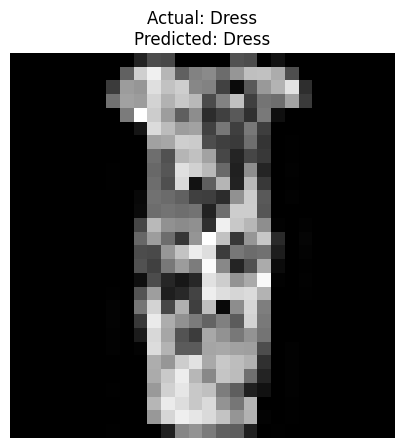

In [ ]:
# 19. Display Identified Image

plt.figure(figsize=(5, 5))

plt.imshow(
    image.reshape(28, 28),
    cmap='gray'
)

plt.title(
    "Actual: " + class_names[y_test[index]]
    + "\nPredicted: " + class_names[predicted_class]
)

plt.axis('off')

plt.show()


Upload an image
----------------


Saving Screenshot 2026-08-11 112105.png to Screenshot 2026-08-11 112105 (2).png

Image Recognition Result
------------------------
Predicted Class : Bag
Confidence      : 100.0 %


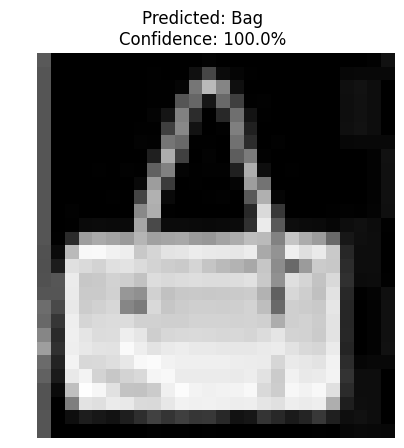

In [ ]:
print("\nUpload an image")
print("----------------")

uploaded = files.upload()

file_name = list(uploaded.keys())[0]
img = Image.open(file_name)
img = img.convert('L')
img = img.resize((28, 28))
img_array = np.array(img)
# Normalize pixel values
img_array = img_array / 255.0

if np.mean(img_array) > 0.5:
    img_array = 1 - img_array


# Reshape for CNN
img_input = img_array.reshape(1, 28, 28, 1)

# 22. Predict Image

prediction = model.predict(
    img_input,
    verbose=0
)

predicted_class = np.argmax(prediction[0])

confidence = prediction[0][predicted_class] * 100

# 23. Display Result
print("\nImage Recognition Result")
print("------------------------")

print("Predicted Class :", class_names[predicted_class])

print("Confidence      :", round(confidence, 2), "%")


plt.figure(figsize=(5, 5))

plt.imshow(img_array, cmap='gray')

plt.title(
    "Predicted: " +
    class_names[predicted_class] +
    "\nConfidence: " +
    str(round(confidence, 2)) +
    "%"
)

plt.axis('off')

plt.show()